In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

In [3]:
df = pd.read_csv('logistics_shipments_dataset 2.csv')

In [4]:
df = df.dropna(subset=['Origin_Warehouse','Destination','Carrier','Weight_kg','Cost'])

In [5]:
df.shape

(1959, 11)

In [6]:
df.dtypes

Shipment_ID          object
Origin_Warehouse     object
Destination          object
Carrier              object
Shipment_Date        object
Delivery_Date        object
Weight_kg           float64
Cost                float64
Status               object
Distance_miles        int64
Transit_Days          int64
dtype: object

In [7]:
df.isnull().sum()

Shipment_ID          0
Origin_Warehouse     0
Destination          0
Carrier              0
Shipment_Date        0
Delivery_Date       31
Weight_kg            0
Cost                 0
Status               0
Distance_miles       0
Transit_Days         0
dtype: int64

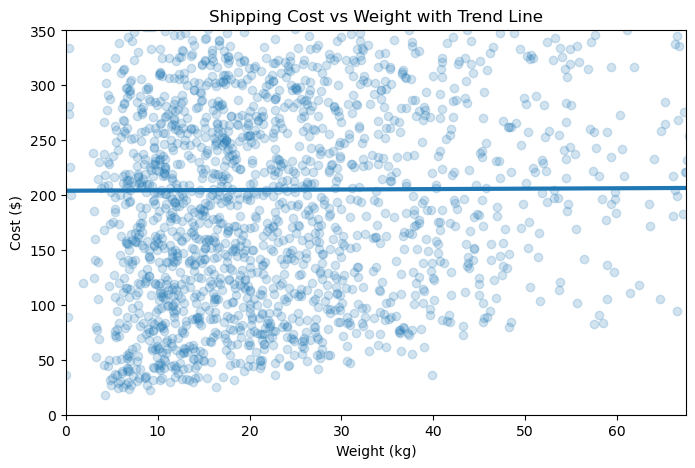

In [8]:
z = np.polyfit(df["Weight_kg"], df["Cost"], 1)
p = np.poly1d(z)

x = np.linspace(0, df["Weight_kg"].quantile(0.95), 100)

plt.figure(figsize=(8, 5))
plt.scatter(df["Weight_kg"], df["Cost"], alpha=0.2)
plt.plot(x, p(x), linewidth=3)

plt.xlim(0, df["Weight_kg"].quantile(0.95))
plt.ylim(0, df["Cost"].quantile(0.95))

plt.xlabel("Weight (kg)")
plt.ylabel("Cost ($)")
plt.title("Shipping Cost vs Weight with Trend Line")
plt.show()

In [9]:
carrier_avg = df.groupby("Carrier")["Cost"].mean()
carrier_avg.plot(kind="bar")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

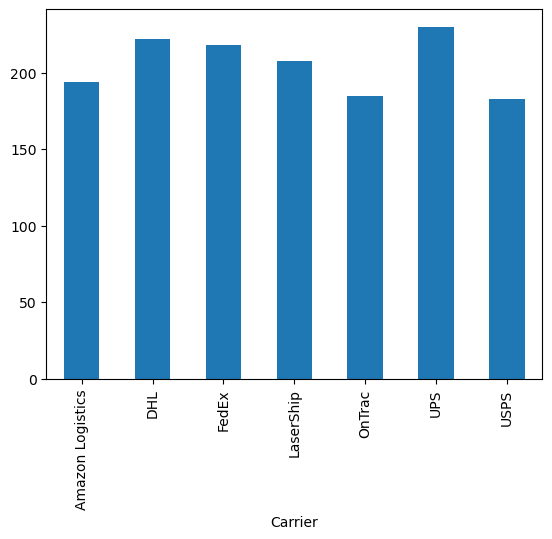

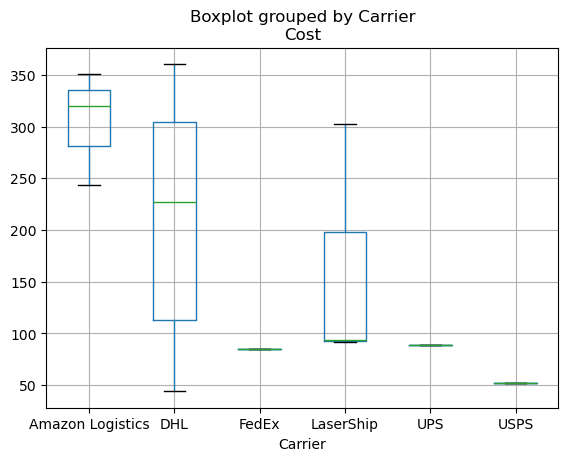

In [10]:
route_df = df[
    (df["Origin_Warehouse"] == "Warehouse_ATL") &
    (df["Destination"] == "Chicago")
]
route_df.boxplot(column="Cost", by="Carrier")
plt.show()

In [24]:
x1 = df.groupby("Carrier")["Cost"].mean()
y1 = df.groupby("Carrier")["Weight_kg"].mean()
x1y1 = pd.DataFrame(x1).join(y1)
print(x1y1)

                        Cost  Weight_kg
Carrier                                
Amazon Logistics  193.909251  26.005243
DHL               222.134764  25.025455
FedEx             217.965952  46.398980
LaserShip         207.857905  28.936824
OnTrac            184.599017  26.598305
UPS               229.714542  25.998805
USPS              182.661032  31.846619


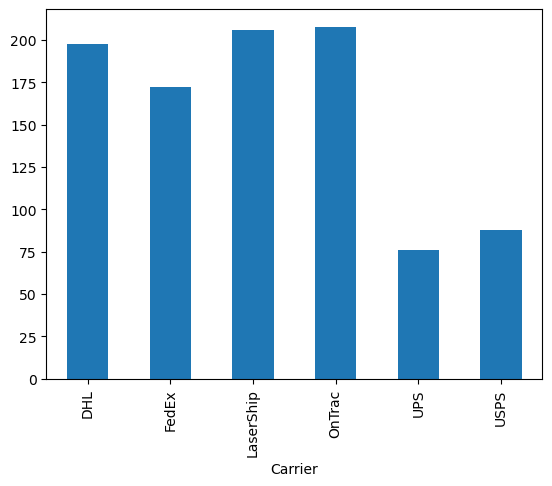

In [22]:
route_df1 = df[
    (df["Origin_Warehouse"] == "Warehouse_SEA") &
    (df["Destination"] == "Houston")
]
carrier_avg2 = route_df1.groupby("Carrier")["Cost"].mean()
carrier_avg2.plot(kind="bar")
plt.show()

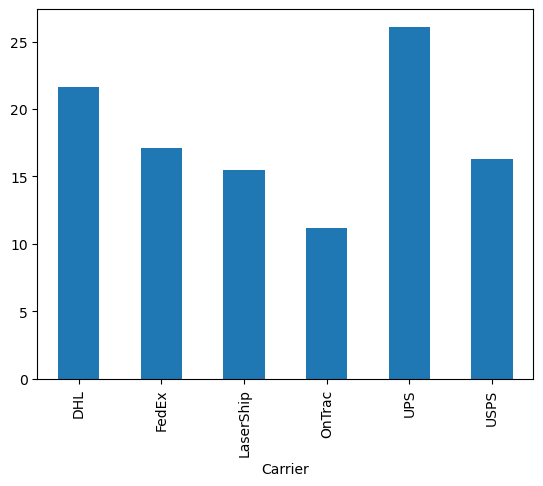

In [23]:
route_df1 = df[
    (df["Origin_Warehouse"] == "Warehouse_SEA") &
    (df["Destination"] == "Houston")
]
carrier_avg2 = route_df1.groupby("Carrier")["Weight_kg"].mean()
carrier_avg2.plot(kind="bar")
plt.show()